In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("messy_clinic_appointments.csv")
df

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2/26/2026,12/3/2024,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,5/23/2025,12-Jun-24,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-25,5-Aug-24,Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,18-May-25,9/9/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,3/7/2026,8/17/2024,Andrea Hernandez,General,$84.44,1
...,...,...,...,...,...,...,...,...,...,...
995,1082,Thomas Roman,64,Female,14-Sep-25,7/15/2024,Robert Bass,General,Rs200.43,Yes
996,1008,Jack Cooper,67,F,9-Apr-25,20-Jun-24,Christopher Smith,General,Rs244.49,No
997,1022,Christopher Brown,28,1,13-Feb-26,6/13/2024,Kimberly Johnson,Neurology,£154.48,N
998,1088,Michael Sullivan,65,F,7/4/2025,4/15/2024,Anthony Mccoy,Neurology,$434.95,0


In [2]:
#Understanding the structure and information  of the dataset
#df.info()
df.describe()
df.head(10)


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2/26/2026,12/3/2024,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,5/23/2025,12-Jun-24,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-25,5-Aug-24,Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,18-May-25,9/9/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,3/7/2026,8/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,26-Sep-25,8/31/2025,Kimberly Fields,General,NaN,Yes
6,1018,Alexander Harris,22,Female,30-Oct-25,12/29/2024,Jim Jones,Cardiology,€99.0,No
7,1074,Raymond Williams,57,M,4/23/2025,28-Mar-25,James Brooks,Neurology,Rs374.63,No
8,1041,Dustin Willis,54,female,22-Aug-25,11/7/2024,Jamie Hill,General,$452.37,Yes
9,1011,Tina Gallagher,45,M,3/16/2026,12-Dec-25,Tiffany Gates MD,Neurology,€494.97,Yes


In [3]:
#	Inspect the first few rows and overall structure.
df.shape          # (12, 9)

(1000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          1000 non-null   int64 
 1   patient_name        1000 non-null   object
 2   age                 1000 non-null   int64 
 3   gender              950 non-null    object
 4   appointment_date    1000 non-null   object
 5   booking_date        1000 non-null   object
 6   doctor              1000 non-null   object
 7   department          1000 non-null   object
 8   billing_amount      950 non-null    object
 9   follow_up_required  1000 non-null   object
dtypes: int64(2), object(8)
memory usage: 78.3+ KB


In [5]:
#Cleaning data sets
#1. Missing Values & Duplicates
#2.Standardizing gender field( "M", "Male", and "1" all mean the same thing. Let's force them into a unified format.)
#3.Date Standardization
#4.Cleaning Billing field(The billing_amount column is a mess of symbols ($ , €, £, Rs). We’ll strip the non-numeric characters and convert it to a float)
#5.The "Follow-Up" Filter (Boolean Uniformity)
#6.Finally, we’ll trim whitespace from strings and ensure the age column is a proper integer.

In [6]:
#1. Missing Values & Duplicates
#check for Missing values
df.isnull().sum()   # count of nulls per column


patient_id             0
patient_name           0
age                    0
gender                50
appointment_date       0
booking_date           0
doctor                 0
department             0
billing_amount        50
follow_up_required     0
dtype: int64

In [7]:
# Remove duplicate records
df = df.drop_duplicates()
print(df.duplicated().sum())        # 50
int(df.duplicated().sum())

0


0

In [8]:
# Standardize 'N/A' strings to actual NaN and handle missing values
df = df.replace(['N/A', 'null', 'None', ''], pd.NA)

# drop rows where critical ID or Name is missing
df = df.dropna(subset=['patient_id', 'patient_name'])
print(f"Cleaned duplicates and nulls. Remaining rows: {len(df)}")


Cleaned duplicates and nulls. Remaining rows: 1000


In [9]:
# Mapping inconsistent gender values to a standard format
gender_mapping = {
    'M': 'Male', 'Male': 'Male', '1': 'Male', 'male': 'Male',
    'F': 'Female', 'Female': 'Female', '0': 'Female', 'female': 'Female'
}

df['gender'] = df['gender'].map(gender_mapping).fillna('Other')
print("Gender distribution standardized:")
print(df['gender'].value_counts())

Gender distribution standardized:
gender
Female    477
Male      473
Other      50
Name: count, dtype: int64


In [10]:
#3.Date Standardization
# The raw columns mix two formats: "2/26/2026" (M/D/YYYY) and "30-Nov-25" (D-MMM-YY).
# Parsing in a single pass makes pandas infer one format and coerce everything else
# to NaT, silently dropping about half the rows. Parse each format separately and
# combine so no valid date is lost.
dates = ['appointment_date', 'booking_date']

for col in dates:
    slash  = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')
    dashed = pd.to_datetime(df[col], format='%d-%b-%y', errors='coerce')
    df[col] = slash.fillna(dashed)
    print(f"{col}: {df[col].notna().sum()}/{len(df)} parsed")

print("Dates standardized to YYYY-MM-DD.")
df

appointment_date: 1000/1000 parsed
booking_date: 1000/1000 parsed
Dates standardized to YYYY-MM-DD.


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,Female,2026-02-26,2024-12-03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,Female,2025-05-23,2024-06-12,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,Male,2025-11-30,2024-08-05,Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,Female,2025-05-18,2024-09-09,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,Other,2026-03-07,2024-08-17,Andrea Hernandez,General,$84.44,1
...,...,...,...,...,...,...,...,...,...,...
995,1082,Thomas Roman,64,Female,2025-09-14,2024-07-15,Robert Bass,General,Rs200.43,Yes
996,1008,Jack Cooper,67,Female,2025-04-09,2024-06-20,Christopher Smith,General,Rs244.49,No
997,1022,Christopher Brown,28,Male,2026-02-13,2024-06-13,Kimberly Johnson,Neurology,£154.48,N
998,1088,Michael Sullivan,65,Female,2025-07-04,2024-04-15,Anthony Mccoy,Neurology,$434.95,0


In [11]:
#4.Cleaning Billing field(The billing_amount column is a mess of symbols ($ , €, £, Rs). We’ll strip the non-numeric characters and convert it to a float)
# Use regex to keep only numbers and decimals
df['billing_amount'] = df['billing_amount'].replace(r'[^\d.]', '', regex=True).astype(float)

print(f"Average billing amount: {df['billing_amount'].mean():.2f}")

Average billing amount: 276.12


In [12]:
# Standardize follow-up responses
follow_up_map = {
    'Yes': 1, 'Y': 1, '1': 1, 1: 1,
    'No': 0, 'N': 0, '0': 0, 0: 0
}

df['follow_up_required'] = df['follow_up_required'].map(follow_up_map).fillna(0).astype(int)
print("Follow-up required column normalized.")

Follow-up required column normalized.


In [13]:
#Remove whitespace

df = df.apply(lambda x: x.str.strip() if x.dtype in ["object", "string"] else x)
print("--- Final Dataset Info ---")
df.info()
df.head(10)



--- Final Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          1000 non-null   int64         
 1   patient_name        1000 non-null   object        
 2   age                 1000 non-null   int64         
 3   gender              1000 non-null   object        
 4   appointment_date    1000 non-null   datetime64[ns]
 5   booking_date        1000 non-null   datetime64[ns]
 6   doctor              1000 non-null   object        
 7   department          1000 non-null   object        
 8   billing_amount      950 non-null    float64       
 9   follow_up_required  1000 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(4)
memory usage: 78.3+ KB


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,Female,2026-02-26,2024-12-03,Christopher Graham,Cardiology,425.80,1
1,1074,Megan Strickland,69,Female,2025-05-23,2024-06-12,Brandon Lewis,Orthopedics,344.26,1
2,1067,Amanda Schroeder,79,Male,2025-11-30,2024-08-05,Deanna Edwards,Neurology,203.34,1
3,1072,Anthony Mcpherson,47,Female,2025-05-18,2024-09-09,Karen Parsons,General,85.76,0
4,1092,Benjamin Brown,45,Other,2026-03-07,2024-08-17,Andrea Hernandez,General,84.44,1
5,1057,Joe Sharp,78,Male,2025-09-26,2025-08-31,Kimberly Fields,General,NaN,1
6,1018,Alexander Harris,22,Female,2025-10-30,2024-12-29,Jim Jones,Cardiology,99.00,0
7,1074,Raymond Williams,57,Male,2025-04-23,2025-03-28,James Brooks,Neurology,374.63,0
8,1041,Dustin Willis,54,Female,2025-08-22,2024-11-07,Jamie Hill,General,452.37,1
9,1011,Tina Gallagher,45,Male,2026-03-16,2025-12-12,Tiffany Gates MD,Neurology,494.97,1


In [14]:
#Exploratory Data Analysis

In [15]:
#Check for unique department
df.department.nunique()

4

In [16]:
#check total patient for each doctor
df['doctor'].value_counts()

doctor
Nancy Hernandez       2
Kristen Lopez         2
Michael Wright        2
Benjamin Brown        2
James Aguilar         2
                     ..
Logan Cooper          1
Nathaniel Thompson    1
Natalie Turner        1
Kurt Cain             1
Marvin Hicks          1
Name: count, Length: 990, dtype: int64

In [17]:
df["gender"].value_counts(normalize=True)

gender
Female    0.477
Male      0.473
Other     0.050
Name: proportion, dtype: float64

<Axes: >

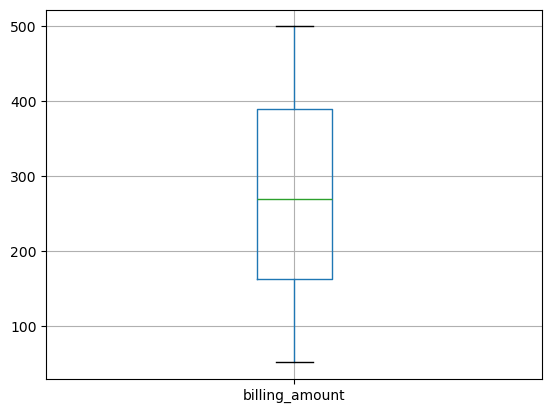

In [18]:
#check for outliers

import matplotlib.pyplot as plt
import seaborn as sns
q1, q3 = df["billing_amount"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df["billing_amount"] < q1 - 1.5*iqr) | (df["billing_amount"] > q3 + 1.5*iqr)]
df.boxplot(column="billing_amount")

#Analyze which age category mostly goes to which department


In [19]:
#Binning age groups

bins   = [18, 35, 50, 65, 91]
labels = ["18-34", "35-49", "50-64", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)


In [20]:
ct = pd.crosstab(df["age_group"], df["department"])
print(ct)

department  Cardiology  General  Neurology  Orthopedics
age_group                                              
18-34               56       60         63           72
35-49               44       34         43           57
50-64               50       49         72           46
65+                 84       88         95           87


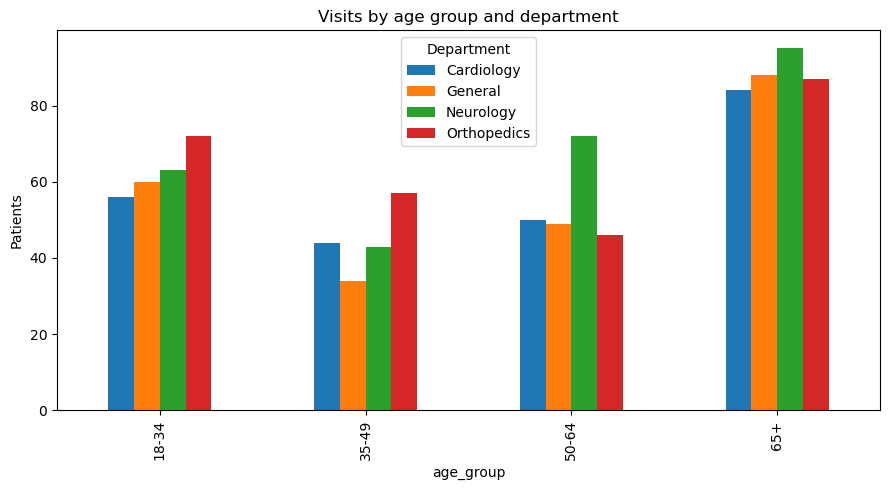

In [21]:
#Grouped bar chart
ct.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Patients")
plt.title("Visits by age group and department")
plt.legend(title="Department")
plt.tight_layout()
plt.show()

Test whether the pattern is real rather than random variation:

In [22]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(ct)
print(f"chi2={chi2:.2f}  p={p:.4f}")   # p < 0.05 means age group and department are related

chi2=11.28  p=0.2571


In [23]:
# 0/1 column: sum = number of follow-ups, mean = follow-up rate
fu = (df.groupby("age_group", observed=True)["follow_up_required"]
        .agg(patients="size", follow_ups="sum", rate="mean"))
fu["rate"] = (fu["rate"] * 100).round(1)
print(fu.sort_values("rate", ascending=False))

           patients  follow_ups  rate
age_group                            
65+             354         192  54.2
18-34           251         132  52.6
50-64           217         111  51.2
35-49           178          79  44.4


In [24]:
fu["rate"].plot(kind="bar", color="#0B5394", ylabel="% needing follow-up",
                title="Follow-up rate by age group")

pd.crosstab(df["age_group"], df["department"],
            values=df["follow_up_required"], aggfunc="mean").mul(100).round(1)

department,Cardiology,General,Neurology,Orthopedics
age_group,,,,
18-34,55.4,53.3,50.8,51.4
35-49,36.4,52.9,48.8,42.1
50-64,46.0,51.0,54.2,52.2
65+,59.5,56.8,50.5,50.6
